**Weblife Assignment**

**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Importing the Dataset**

In [2]:
df = pd.read_csv('F:\Applied Jobs\Weblife\Ecommerce_Strategic_Assignment_Dataset (2).csv')

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\HP\AppData\Local\Temp\ipykernel_9276\3526372464.py:1: SyntaxWarning: invalid escape sequence '\A'
  df = pd.read_csv('F:\Applied Jobs\Weblife\Ecommerce_Strategic_Assignment_Dataset (2).csv')


**Initial Exploration & Cleaning**

In [3]:
# Identifying the first 5 rows of the dataframe
df.head()

,Date,Traffic_Source,Campaign,Customer_Type,Visitors,Marketing_Spend,Add_to_Cart,Purchases,Revenue,Cart_Abandonment_Rate,Repeat_Purchase_Rate,Conversion_Rate
0,1/1/2023,Email Campaign,Flash Deals,New,1226,1469.85,261,46.0,6416.70,19.11,20.99,8.91
1,1/2/2023,Social Media,Flash Deals,New,1559,4429.12,274,153.0,6692.86,49.04,21.91,7.08
2,1/3/2023,Direct,Winter Promo,New,960,3763.82,69,238.0,4355.64,36.69,8.29,5.92
3,1/4/2023,Direct,Flash Deals,New,1394,4770.05,162,187.0,5613.54,10.42,10.85,8.47
4,1/5/2023,Organic Search,Summer Sale,Returning,1230,1720.68,189,117.0,4717.28,20.22,24.67,6.46


In [4]:
# Convert all column names to lowercase
df.columns = df.columns.str.lower()

In [5]:
# Identifying data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   450 non-null    object 
 1   traffic_source         450 non-null    object 
 2   campaign               450 non-null    object 
 3   customer_type          450 non-null    object 
 4   visitors               450 non-null    int64  
 5   marketing_spend        405 non-null    float64
 6   add_to_cart            450 non-null    int64  
 7   purchases              405 non-null    float64
 8   revenue                405 non-null    float64
 9   cart_abandonment_rate  450 non-null    float64
 10  repeat_purchase_rate   450 non-null    float64
 11  conversion_rate        450 non-null    float64
dtypes: float64(6), int64(2), object(4)
memory usage: 42.3+ KB


In [6]:
# Changing the 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y')

In [7]:
# Identifying null values
df.isnull().sum()

date                      0
traffic_source            0
campaign                  0
customer_type             0
visitors                  0
marketing_spend          45
add_to_cart               0
purchases                45
revenue                  45
cart_abandonment_rate     0
repeat_purchase_rate      0
conversion_rate           0
dtype: int64

In [ ]:
# Replacing null values with the median of the respective columns
df['marketing_spend'].fillna(df['marketing_spend'].median(), inplace=True)
df['purchases'].fillna(df['purchases'].median(), inplace=True)
df['revenue'].fillna(df['revenue'].median(), inplace=True)

**Feature Engineering**

In [9]:
# Extracting day name from 'date' column
df['day_name'] = df['date'].dt.day_name()

In [10]:
# Final dataframe after all adjustments
df.head()

,date,traffic_source,campaign,customer_type,visitors,marketing_spend,add_to_cart,purchases,revenue,cart_abandonment_rate,repeat_purchase_rate,conversion_rate,day_name
0,2023-01-01,Email Campaign,Flash Deals,New,1226,1469.85,261,46.0,6416.70,19.11,20.99,8.91,Sunday
1,2023-01-02,Social Media,Flash Deals,New,1559,4429.12,274,153.0,6692.86,49.04,21.91,7.08,Monday
2,2023-01-03,Direct,Winter Promo,New,960,3763.82,69,238.0,4355.64,36.69,8.29,5.92,Tuesday
3,2023-01-04,Direct,Flash Deals,New,1394,4770.05,162,187.0,5613.54,10.42,10.85,8.47,Wednesday
4,2023-01-05,Organic Search,Summer Sale,Returning,1230,1720.68,189,117.0,4717.28,20.22,24.67,6.46,Thursday


**Exploratory Data Analysis & Visualization**

*Analysing Traffic Sources*

In [11]:
df.groupby('traffic_source').agg({'visitors': 'sum', 'purchases': 'sum', 'revenue': 'sum', 'conversion_rate': 'mean'}).sort_values(by='visitors', ascending=False).round(1)

,visitors,purchases,revenue,conversion_rate
traffic_source,,,,
Direct,114651,16192.0,580494.9,5.3
Google Ads,106263,15691.0,481910.5,5.8
Social Media,98681,13132.0,476650.9,5.7
Email Campaign,89993,14327.0,473327.2,6.0
Organic Search,83300,12182.0,428057.0,5.4


In [12]:
# Direct traffic has the highest number of visitors, purchases and revenue, but the lowest conversion rate. Email campaigns have the highest conversion rate.

*Analysing Campaigns*

In [13]:
df.groupby('campaign').agg({'visitors': 'sum', 'purchases': 'sum', 'revenue': 'sum', 'marketing_spend': 'sum', 'conversion_rate': 'mean'}).sort_values(by='visitors', ascending=False).round(1)

,visitors,purchases,revenue,marketing_spend,conversion_rate
campaign,,,,,
Winter Promo,113115,16269.0,525502.5,241967.3,5.7
Summer Sale,97595,13857.0,501618.2,224654.4,5.5
Flash Deals,97263,13682.0,481636.2,236433.8,5.6
Weekend Discount,93107,13283.0,436835.9,226740.2,5.4
Holiday Offers,91808,14433.0,494847.8,213718.5,6.0


In [14]:
# Winter Promo has the highest number of visitors, purchases and revenue. Holiday Offers, while having the least visitors, has the highest conversion rate.

*Analysing Customer Types*

In [15]:
df.groupby('customer_type').agg({'visitors': 'sum', 'purchases': 'sum', 'revenue': 'sum', 'cart_abandonment_rate': 'mean', 'repeat_purchase_rate': 'mean', 'conversion_rate': 'mean'}).sort_values(by='visitors', ascending=False).round(1)

,visitors,purchases,revenue,cart_abandonment_rate,repeat_purchase_rate,conversion_rate
customer_type,,,,,,
New,252398,36297.0,1250951.3,30.3,18.1,5.8
Returning,240490,35227.0,1189489.3,28.7,17.2,5.4


In [16]:
# The majority of the visitors are new customers and they tend to make more purchases compared to returning customers, while bringing in more revenue.
# Their conversion rates and repeat purchase rates are also higher than returning customers.

*Daily Visitors vs Purchases*

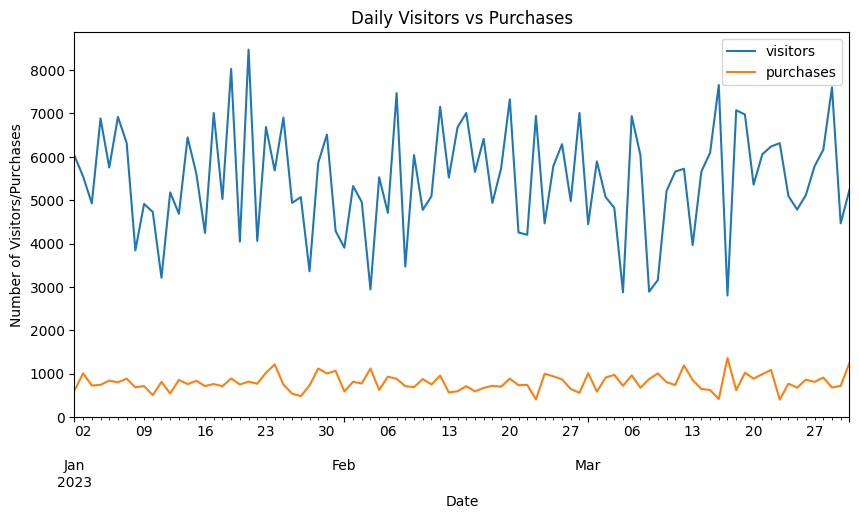

In [17]:
df.groupby('date').agg({'visitors': 'sum', 'purchases': 'sum'}).plot(figsize=(10,5))
plt.title('Daily Visitors vs Purchases')
plt.xlabel('Date')
plt.ylabel('Number of Visitors/Purchases')
plt.show()

*Visitors by Traffic Source*

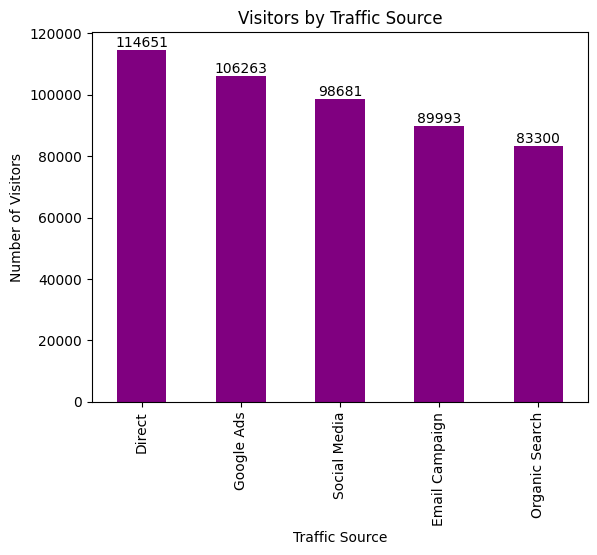

In [18]:
df.groupby('traffic_source').agg({'visitors': 'sum'}).sort_values(by='visitors', ascending=False).plot(kind='bar', color='purple', legend=False)
plt.title('Visitors by Traffic Source')
plt.xlabel('Traffic Source')
plt.ylabel('Number of Visitors')
plt.bar_label(plt.gca().containers[0])
plt.show()

*Visitors by Day of Week*

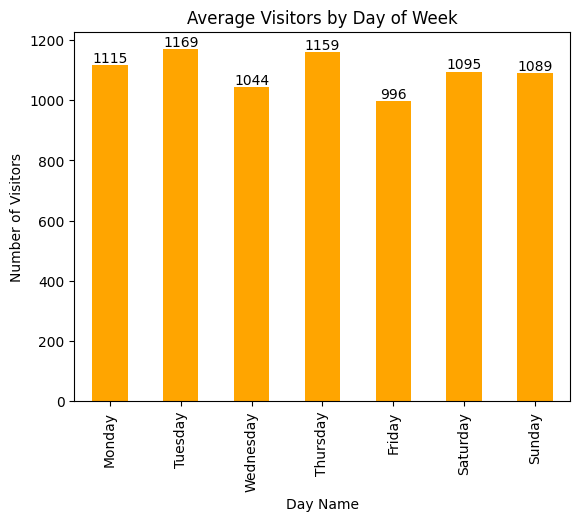

In [19]:
df.groupby('day_name').agg({'visitors': 'mean'}).round().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']).plot(kind='bar', color='orange', legend=False)
plt.title('Average Visitors by Day of Week')
plt.xlabel('Day Name')
plt.ylabel('Number of Visitors')
plt.bar_label(plt.gca().containers[0])
plt.show()

*Daily Revenue*

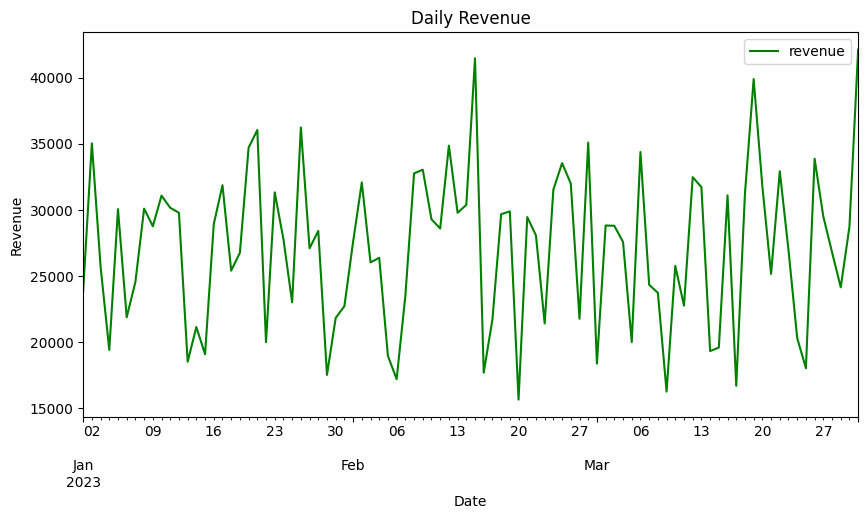

In [20]:
df.groupby('date').agg({'revenue': 'sum'}).plot(color ='green', figsize=(10,5))
plt.title('Daily Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.show()

*Revenue by Traffic Source*

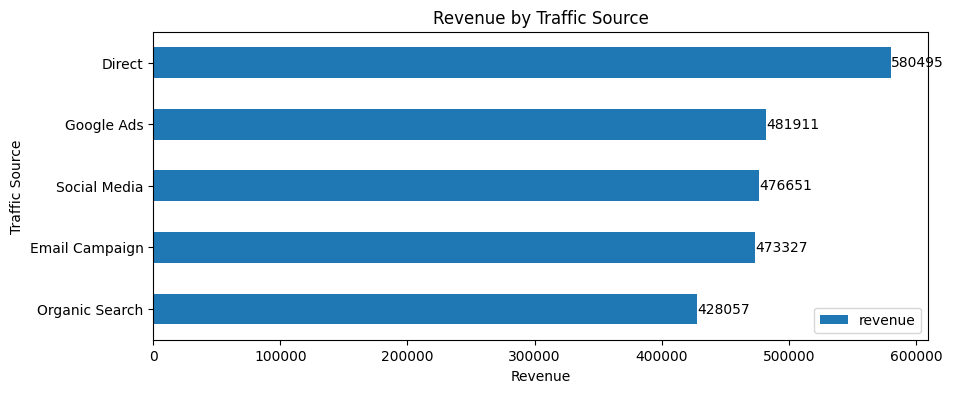

In [21]:
df.groupby('traffic_source').agg({'revenue': 'sum'}).sort_values(by='revenue', ascending=True).plot(kind='barh', figsize=(10,4))
plt.title('Revenue by Traffic Source')
plt.xlabel('Revenue')
plt.ylabel('Traffic Source')
plt.bar_label(plt.gca().containers[0])
plt.show()

*Revenue by Traffic Source*

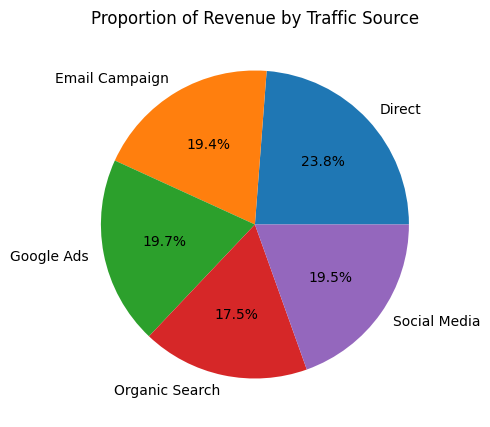

In [22]:
df.groupby('traffic_source').agg({'revenue': 'sum'}).plot(kind='pie', y='revenue', autopct='%1.1f%%', figsize=(5,5), legend=False, ylabel='')
plt.title('Proportion of Revenue by Traffic Source')
plt.show()

*Retrun on Ad Spend by Campaign*

                  marketing_spend    revenue  roas
campaign                                          
Flash Deals             236433.79  481636.16  2.04
Holiday Offers          213718.49  494847.81  2.32
Summer Sale             224654.40  501618.25  2.23
Weekend Discount        226740.22  436835.86  1.93
Winter Promo            241967.27  525502.49  2.17


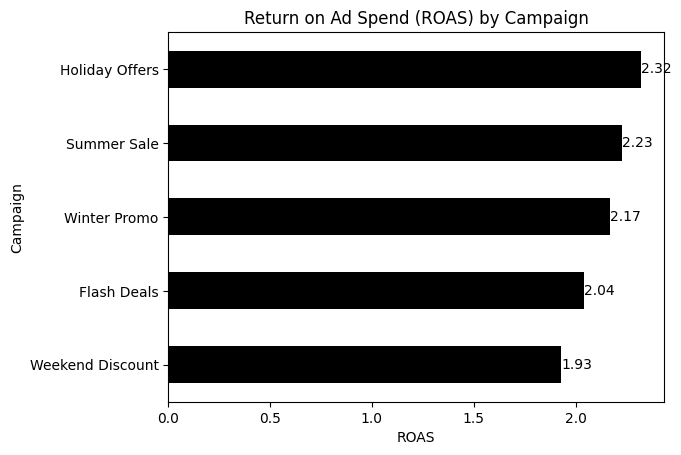

In [23]:
pivot = df.pivot_table(index='campaign', values=['revenue', 'marketing_spend'], aggfunc='sum')
pivot['roas'] = round(pivot['revenue'] / pivot['marketing_spend'], 2)
print(pivot)
pivot['roas'].sort_values(ascending=True).plot(kind='barh', color = 'black')
plt.title('Return on Ad Spend (ROAS) by Campaign')
plt.xlabel('ROAS')
plt.ylabel('Campaign')
plt.bar_label(plt.gca().containers[0])
plt.show()

*Cart Abandonment Rate by Traffic Source*

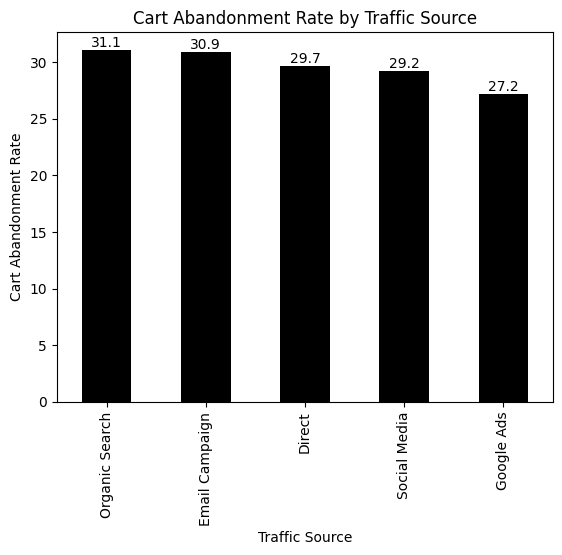

In [24]:
df.groupby('traffic_source').agg({'cart_abandonment_rate': 'mean'}).round(1).sort_values(by='cart_abandonment_rate', ascending=False).plot(kind = 'bar', color='black', legend=False)
plt.title('Cart Abandonment Rate by Traffic Source')
plt.xlabel('Traffic Source')
plt.ylabel('Cart Abandonment Rate')
plt.bar_label(plt.gca().containers[0])
plt.show()

*Repeat Purchase Rate by Traffic Source*

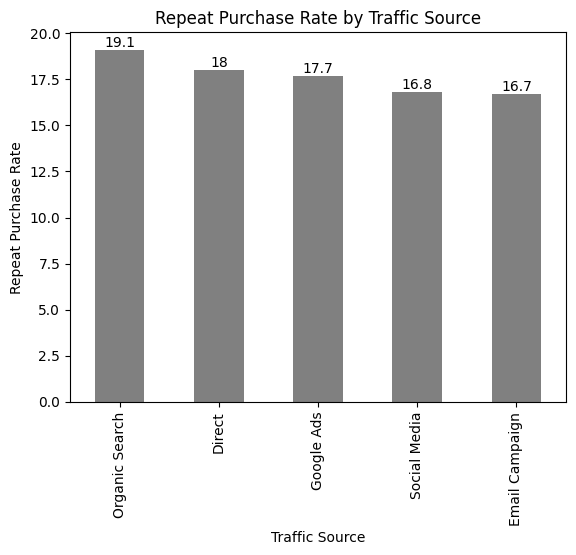

In [25]:
df.groupby('traffic_source').agg({'repeat_purchase_rate': 'mean'}).round(1).sort_values(by='repeat_purchase_rate', ascending=False).plot(kind='bar', color='grey', legend=False)
plt.title('Repeat Purchase Rate by Traffic Source')
plt.xlabel('Traffic Source')
plt.ylabel('Repeat Purchase Rate')
plt.bar_label(plt.gca().containers[0])
plt.show()

**Exporting Data as CSV file**

In [ ]:
# df.to_csv('F:\Applied Jobs\Weblife\Ecommerce_Strategic_Assignment_Dataset_Clean.csv', index=False) 

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\HP\AppData\Local\Temp\ipykernel_9276\626362457.py:1: SyntaxWarning: invalid escape sequence '\A'
  df.to_csv('F:\Applied Jobs\Weblife\Ecommerce_Strategic_Assignment_Dataset_Clean.csv', index=False)
